#  Synent Technologies Data Science Internship - Task 5: Sales Data Analysis
Intern: [Raj Bhut]

## 1. Introduction

This notebook analyzes the Superstore sales dataset to explore revenue patterns, top-selling products, and performance across categories, regions, and customer segments.
The objective of this task is to analyze business performance using Superstore sales data. The analysis focuses on monthly revenue trends, top-selling products, and business insights.

The uploaded dataset contains `Sales` but does **not** contain `Profit`, `Quantity`, or `Discount` columns. Therefore, this notebook performs revenue, product, region, category, and customer-segment analysis. Profit analysis is documented as unavailable for this dataset version unless a Superstore file with a `Profit` column is provided.

## 2. Setup: Import Libraries

Import the required Python libraries and load the dataset from the local Downloads folder.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Data Loading and Inspection

Load the CSV file, inspect the shape, columns, missing values, and duplicates.

In [2]:
DATA_PATH = r"c:\Users\Admin\Downloads\superstoresales.csv"

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"CSV not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Missing values:


Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


Duplicate rows: 0


In [4]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

# Add time-based fields
df["order_month"] = df["Order Date"].dt.to_period("M").astype(str)
df["order_year"] = df["Order Date"].dt.year

print("Date range:", df["Order Date"].min(), "to", df["Order Date"].max())
print("Total sales:", round(df["Sales"].sum(), 2))

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Total sales: 2261536.78


## 4. Monthly Revenue Trends

In [5]:
monthly_revenue = (
    df.groupby("order_month", as_index=False)["Sales"]
    .sum()
    .sort_values("order_month")
)

monthly_revenue.tail(10)

,order_month,Sales
38,2018-03,58863.4128
39,2018-04,35541.9101
40,2018-05,43825.9822
41,2018-06,48190.7277
42,2018-07,44825.1040
43,2018-08,62837.8480
44,2018-09,86152.8880
45,2018-10,77448.1312
46,2018-11,117938.1550
47,2018-12,83030.3888


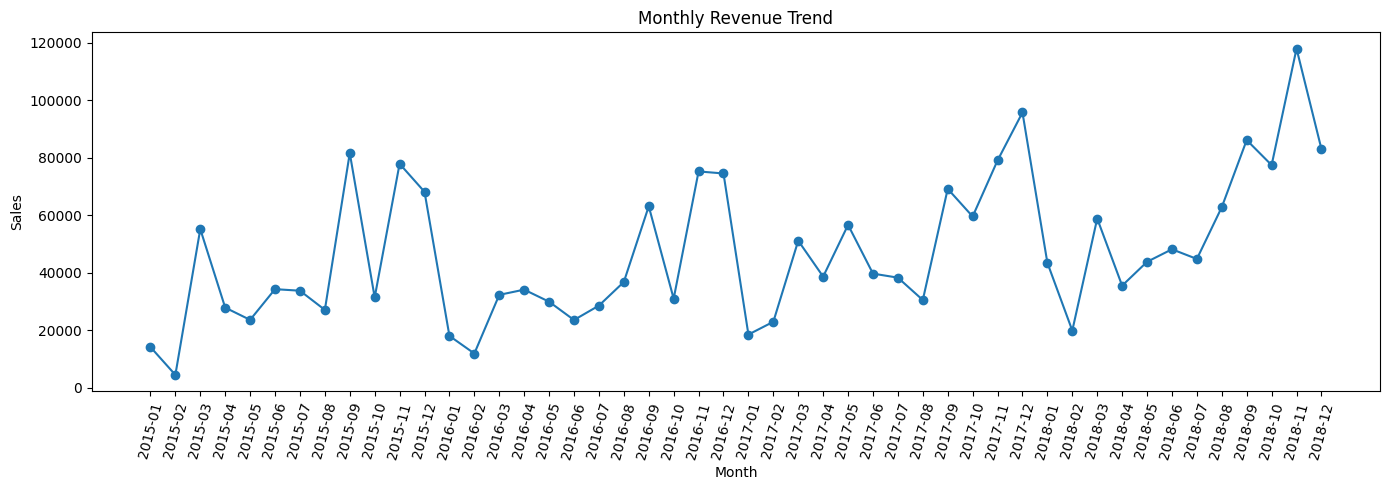

In [6]:
# Optional chart: works in Kaggle/Colab/Jupyter when matplotlib is available.
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 5))
    plt.plot(monthly_revenue["order_month"], monthly_revenue["Sales"], marker="o")
    plt.xticks(rotation=75)
    plt.title("Monthly Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib is not installed. Monthly revenue table is shown above.")

## Top-Selling Products

In [7]:
top_products = (
    df.groupby("Product Name", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)
top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


## Category and Region Performance

In [8]:
category_sales = (
    df.groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

region_sales = (
    df.groupby("Region", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(category_sales)
display(region_sales)

,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


,Region,Sales
3,West,710219.6845
1,East,669518.7260
0,Central,492646.9132
2,South,389151.4590


## Segment Performance

In [9]:
segment_sales = (
    df.groupby("Segment", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)
segment_sales

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


## Profit Analysis Status

The PDF task asks for profit analysis, but this uploaded CSV does not include a `Profit` column. The correct professional handling is to state this clearly instead of inventing profit values.

In [10]:
if "Profit" in df.columns:
    profit_by_category = df.groupby("Category", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False)
    display(profit_by_category)
else:
    print("Profit column is not available in this dataset. Profit analysis cannot be calculated from the uploaded file.")

Profit column is not available in this dataset. Profit analysis cannot be calculated from the uploaded file.


## Final Business Insights

1. Total sales in the dataset are approximately **2,261,536.78**.
2. The highest revenue month is **2018-11**, with sales of approximately **117,938.16**.
3. The top-selling product by revenue is **Canon imageCLASS 2200 Advanced Copier**.
4. The highest-sales category is **Technology**, followed by Furniture and Office Supplies.
5. Profit analysis requires a dataset version that includes a `Profit` column.

## Conclusion

This analysis summarizes Superstore sales performance across time, products, categories, regions, and customer segments. The dataset supports revenue-based insights, but profit analysis is not available because the uploaded file does not include a `Profit` column.

## Project Summary

This project analyzes the Superstore sales dataset to understand revenue trends, product performance, and business distribution across categories, regions, and customer segments. It provides a clear revenue-focused view of sales behavior and documents that profit analysis is not possible with the current CSV because the `Profit` column is missing.